# The Luminal compiler take-home, explained from zero

**Source of truth:** `luminal-challenge/.reference/`, a pinned copy of
`github.com/luminal-ai/interview`. Every rule quoted in this notebook is read
out of that code at run time rather than retyped, so if the reference ever
changed, the cells below would disagree with the prose and you would see it.

**How to run this.** Pick the kernel named **`causalbool`** (top right in
Jupyter, or "Select Kernel" in VS Code). It is
`/Users/alberto/Documents/projects/CausalBool/venv/bin/python`. Then run the
cells in order, top to bottom — each one depends only on the cells above it.
Nothing here writes to the repository, and nothing touches the pinned reference.

**What you will be able to do by the end:** read a program in the challenge's
input language, say what a legal compilation is, build one by hand, watch the
validator reject three different illegal ones, and compute the official score.

---

## 0. Setup

Two directories go on the import path: `.reference/` for the frozen machine and
starter compiler, and the challenge root for our own helper modules.

In [1]:
import json
import math
import sys
from pathlib import Path

ROOT = Path("/Users/alberto/Documents/projects/CausalBool/luminal-challenge").resolve()
for entry in (str(ROOT / ".reference"), str(ROOT)):
    if entry not in sys.path:
        sys.path.insert(0, entry)

import machine          # the frozen machine model and validator (do not modify)
import compiler         # the starter compiler we are asked to improve
import direct_contract  # our own derived-facts helper, built on top of machine

print("python     :", sys.version.split()[0])
print("machine    :", Path(machine.__file__).relative_to(ROOT))
print("compiler   :", Path(compiler.__file__).relative_to(ROOT))

python     : 3.13.12
machine    : .reference/machine.py
compiler   : .reference/compiler.py


---

## 1. What the challenge actually asks

In one sentence: **you are given a list of arithmetic operations, and you must
decide *when* each one runs and *where* each result is stored.**

That is all a backend compiler does here. There is no parsing, no type
checking, no optimisation of the arithmetic itself. The operations are fixed —
you may not add, remove, reorder in the source, or rewrite any of them. You
decide two things, and only two:

| Decision | Called | Output field |
|---|---|---|
| Which cycle does each operation issue in? | **scheduling** | `bundles` |
| Which scratchpad address does each result live at? | **allocation** | `scratch` |

Your `compile_program(program)` returns exactly this shape:

```python
{
    "scratch": {"some_value": 0, "another_value": 8},
    "bundles": [{"load": [0, 1]}, {}, {"vector": [2], "store": [3]}],
}
```

`bundles[c]` is what issues in cycle `c`, grouped by which engine runs it. The
index into `bundles` *is* the cycle number, so an empty dictionary `{}` is a
stall cycle where nothing issues.

**You are scored on two numbers:** how many cycles the schedule takes, and how
many scratch words it uses. Fewer of both is better. A wrong answer scores
nothing at all — correctness is a gate, not a component.

The starter compiler already works. It issues one operation per cycle and gives
every value its own private address. Your job is to make that tighter without
ever making it wrong.

---

## 2. The input: a program

Programs are JSON. Let us look at a small real one — the whole file, nothing
elided.

In [2]:
PROGRAM_PATH = ROOT / ".reference/programs/02_scalar_dual_chain.json"
program = machine.load_program(PROGRAM_PATH)   # load_program also validates it

print(PROGRAM_PATH.read_text())

{
  "name": "scalar_dual_chain",
  "buffers": {"a": 1, "b": 1, "c": 1, "d": 1, "out": 2},
  "operations": [
    {"id": 0, "op": "load", "dest": "a0", "buffer": "a", "offset": 0},
    {"id": 1, "op": "load", "dest": "b0", "buffer": "b", "offset": 0},
    {"id": 2, "op": "load", "dest": "c0", "buffer": "c", "offset": 0},
    {"id": 3, "op": "load", "dest": "d0", "buffer": "d", "offset": 0},
    {"id": 4, "op": "mul", "dest": "left_product", "args": ["a0", "b0"]},
    {"id": 5, "op": "mul", "dest": "right_product", "args": ["c0", "d0"]},
    {"id": 6, "op": "add", "dest": "cross", "args": ["a0", "c0"]},
    {"id": 7, "op": "add", "dest": "left", "args": ["left_product", "cross"]},
    {"id": 8, "op": "xor", "dest": "right", "args": ["right_product", "cross"]},
    {"id": 9, "op": "store", "args": ["left"], "buffer": "out", "offset": 0},
    {"id": 10, "op": "store", "args": ["right"], "buffer": "out", "offset": 1}
  ],
  "cases": [
    {"a": [13], "b": [5], "c": [21], "d": [9], "out": [0,

Three parts:

- **`buffers`** — named blocks of memory, with their length in words. Here `a`,
  `b`, `c`, `d` hold one word each and `out` holds two.
- **`operations`** — the straight-line program. Each has a unique `id`
  (consecutive from zero), an opcode, and for most of them a `dest`: the name of
  the value it produces. Arguments refer to `dest` names defined *earlier*.
- **`cases`** — concrete input memory images with the expected starting content.
  The grader runs your compiled schedule on each one and compares the final
  memory against an interpretation of the original operations.

"SSA" in the brief simply means **every value is written exactly once and never
reassigned**. That is why `dest` names are unique, and it is what makes "when is
this value alive?" a well-posed question later on.

Read this particular program as a dataflow graph:

```
 a  b   c  d          load a0, b0, c0, d0
  \ /    \ /
  mul    mul          left_product = a0*b0     right_product = c0*d0
    \     /
     \   /   a0 + c0 = cross
      \ /      |
      add     xor                              left = lp + cross   right = rp ^ cross
       |       |
     store   store                             out[0] = left       out[1] = right
```

Two independent chains that share one value, `cross`. Nothing in the source
order says the four loads must happen one after another — that is a choice the
compiler makes, and it is exactly the choice being graded.

In [3]:
facts = direct_contract.derive(program)   # a read-only derived view of the program

print(f"{'id':>3}  {'op':7} {'engine':7} {'lat':>3}  {'dest':14} args")
for op in program["operations"]:
    spec = machine.OP_SPECS[op["op"]]
    print(f"{op['id']:>3}  {op['op']:7} {spec['engine']:7} {spec['latency']:>3}  "
          f"{str(op.get('dest', '-')):14} {op.get('args', [])}")

print("\nvalues that need scratch:", facts.value_names)
print("who consumes each value  :", {k: v for k, v in facts.consumers.items()})

 id  op      engine  lat  dest           args
  0  load    load      3  a0             []
  1  load    load      3  b0             []
  2  load    load      3  c0             []
  3  load    load      3  d0             []
  4  mul     scalar    2  left_product   ['a0', 'b0']
  5  mul     scalar    2  right_product  ['c0', 'd0']
  6  add     scalar    1  cross          ['a0', 'c0']
  7  add     scalar    1  left           ['left_product', 'cross']
  8  xor     scalar    1  right          ['right_product', 'cross']
  9  store   store     1  -              ['left']
 10  store   store     1  -              ['right']

values that need scratch: ('a0', 'b0', 'c0', 'd0', 'left_product', 'right_product', 'cross', 'left', 'right')
who consumes each value  : {'a0': (4, 6), 'b0': (4,), 'c0': (5, 6), 'd0': (5,), 'left_product': (7,), 'right_product': (8,), 'cross': (7, 8), 'left': (9,), 'right': (10,)}


---

## 3. The machine: the rules you must obey

Everything below is read out of `machine.py`. Five rules matter.

**Rule 1 — engines have a fixed number of slots per cycle.** Every opcode runs
on exactly one engine, and only so many of them fit in a bundle.

In [4]:
print("engine slots per cycle:", machine.ENGINE_LIMITS)
print()
by_engine = {}
for name, spec in machine.OP_SPECS.items():
    by_engine.setdefault(spec["engine"], []).append((name, spec["latency"]))
for engine, ops in by_engine.items():
    listing = ", ".join(f"{n}({l})" for n, l in ops)
    print(f"{engine:7} x{machine.ENGINE_LIMITS[engine]}  {listing}")
print("\n(the number in brackets is the latency)")

engine slots per cycle: {'load': 2, 'scalar': 2, 'vector': 2, 'store': 1, 'flow': 1}

load    x2  const(1), load(3), vload(4)
store   x1  store(1), vstore(1)
scalar  x2  add(1), sub(1), mul(2), xor(1), and(1), or(1), shl(1), shr(1), eq(1), lt(1)
vector  x2  vadd(1), vsub(1), vmul(3), vxor(1), vand(1), vor(1), vshl(1), vshr(1), splat(1)
flow    x1  select(1), vselect(2)

(the number in brackets is the latency)


**Rule 2 — latency.** An operation issued in cycle `c` produces its result at
cycle `c + latency`. It is *not* available in the same bundle. A `mul` issued in
cycle 3 can be read no earlier than cycle 5.

**Rule 3 — the scratchpad.** 256 words, each a 32-bit unsigned integer. There
are no registers. Every value that is produced must be given an address before
anything can read it. Scalars take one word; vectors take eight consecutive
words and must start at an address divisible by eight.

**Rule 4 — values may share addresses, but only when they are not alive at the
same time.** A value's live interval starts at its *write* cycle (issue +
latency) and ends at its last consumer's *issue* cycle, inclusive. Writes happen
before reads within a cycle, so a new value may take over an address only if it
writes strictly after the old value's final read.

**Rule 5 — memory ordering.** Loads may float freely past one another, but a
store must stay after every earlier overlapping access and before every later
one, and two ordered memory operations may not share a cycle. Ranges that
provably do not overlap are free to reorder. (We demonstrate this in §9.)

The score's memory term is the **footprint**: the highest end address used,
holes included. Putting one vector at address 8 costs 16 words even if
addresses 0 to 7 are empty.

In [5]:
print("scratch words          :", machine.SCRATCH_WORDS)
print("vector length / align  :", machine.VLEN)
print("a vector at address 8 costs a footprint of:", 8 + machine.VLEN, "words")

scratch words          : 256
vector length / align  : 8
a vector at address 8 costs a footprint of: 16 words


---

## 4. The starter compiler, and what it costs

The starter does the simplest correct thing: it walks the operations in source
order, stalls until each one's inputs are ready, and puts each into its own
bundle. Allocation is equally plain — every value gets its own private address.

In [6]:
starter = compiler.compile_program(program)

starter_cycles = machine.check_compilation(program, starter)      # raises if illegal
for case in program["cases"]:
    machine.check_case(program, starter, case)                    # raises if wrong

starter_words = machine.scratch_footprint(program, starter)
print(f"starter: {starter_cycles} cycles, {starter_words} scratch words")
print("scratch map:", starter["scratch"])

starter: 12 cycles, 9 scratch words
scratch map: {'a0': 0, 'b0': 1, 'c0': 2, 'd0': 3, 'left_product': 4, 'right_product': 5, 'cross': 6, 'left': 7, 'right': 8}


`check_compilation` is the validator; `check_case` actually simulates the
schedule on the machine and compares the resulting memory with a direct
interpretation of the source program. Both raise `machine.CompileError` on
anything illegal, so "no exception" is the definition of correct here.

Now render the schedule. A picture of the bundles makes the waste obvious.

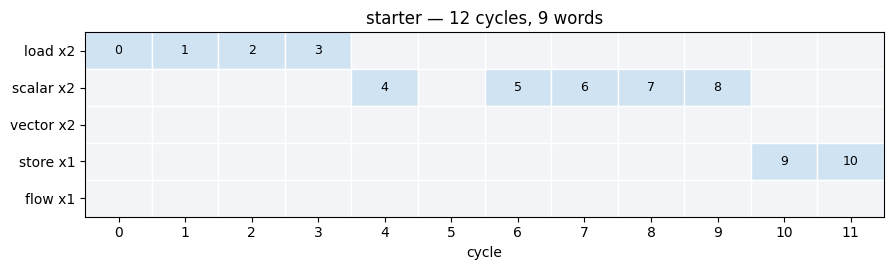

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

ENGINES = ["load", "scalar", "vector", "store", "flow"]


def show_timeline(bundles, title, figure_width=0.62):
    """Draw one column per cycle, one row per engine."""
    n = len(bundles)
    fig, ax = plt.subplots(figsize=(max(4.0, figure_width * n + 1.6), 2.8))
    for row, engine in enumerate(ENGINES):
        for cycle, bundle in enumerate(bundles):
            ids = bundle.get(engine, [])
            ax.add_patch(Rectangle((cycle, row), 1, 1, linewidth=1,
                                   edgecolor="white",
                                   facecolor="#cfe3f3" if ids else "#f2f4f7"))
            if ids:
                ax.text(cycle + 0.5, row + 0.5, ",".join(str(i) for i in ids),
                        ha="center", va="center", fontsize=9)
    ax.set_xlim(0, n)
    ax.set_ylim(0, len(ENGINES))
    ax.set_xticks([c + 0.5 for c in range(n)], [str(c) for c in range(n)])
    ax.set_yticks([r + 0.5 for r in range(len(ENGINES))],
                  [f"{e} x{machine.ENGINE_LIMITS[e]}" for e in ENGINES])
    ax.set_xlabel("cycle")
    ax.set_title(title)
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()


show_timeline(starter["bundles"],
              f"starter — {starter_cycles} cycles, {starter_words} words")

Almost every slot is empty. Two things are being wasted at once:

- **Time.** The four loads are independent, the `load` engine has two slots, and
  yet they occupy four separate cycles.
- **Space.** Nine values get nine private addresses, although most of them are
  dead long before the program ends.

How much room is there, in principle? Two lower bounds are cheap to compute and
both are honest limits no schedule can beat.

In [8]:
print("dependency lower bound (longest latency chain + 1):", facts.dependency_lower_bound())
print("engine lower bound (slots needed / slots per cycle):", facts.engine_lower_bound())
print("=> no legal schedule of this program is shorter than:", facts.cycle_lower_bound(), "cycles")
print("   the starter takes:", starter_cycles)

dependency lower bound (longest latency chain + 1): 7
engine lower bound (slots needed / slots per cycle): 3
=> no legal schedule of this program is shorter than: 7 cycles
   the starter takes: 12


---

## 5. Building a better schedule by hand

Let us do the compiler's job manually, so the machine rules stop being abstract.
The plan: fill both load slots, then issue each operation the moment its inputs
have landed.

| cycle | reasoning |
|---:|---|
| 0 | loads 0 and 1 — the `load` engine has two slots, so use both |
| 1 | loads 2 and 3 |
| 3 | `a0`, `b0` landed at 0+3=3, so `mul` (id 4) may issue |
| 4 | `c0`, `d0` landed at 4: `mul` (5) and `add` (6) — two scalar slots, exactly the limit |
| 5 | `left_product` landed at 3+2=5 and `cross` at 4+1=5, so `add` (7) issues |
| 6 | `right_product` landed at 6 → `xor` (8); `left` landed at 6 → `store` (9) |
| 7 | `right` landed at 7 → `store` (10) |

A schedule is nothing more than this table: a map from operation id to issue
cycle. `direct_contract.assemble_bundles` turns it into the `bundles` list.

In [9]:
times = {0: 0, 1: 0, 2: 1, 3: 1, 4: 3, 5: 4, 6: 4, 7: 5, 8: 6, 9: 6, 10: 7}

bundles = direct_contract.assemble_bundles(facts, times)
for cycle, bundle in enumerate(bundles):
    print(cycle, bundle if bundle else "(stall)")

0 {'load': [0, 1]}
1 {'load': [2, 3]}
2 (stall)
3 {'scalar': [4]}
4 {'scalar': [5, 6]}
5 {'scalar': [7]}
6 {'scalar': [8], 'store': [9]}
7 {'store': [10]}


---

## 6. Allocation: when can two values share an address?

Now the second decision. First compute each value's live interval, using the
rule from §3: it opens at issue + latency, and closes at the last consumer's
issue cycle.

In [10]:
life = direct_contract.lifetimes(facts, times)

print(f"{'value':15} {'written':>8} {'last read':>10}   interval")
for name in facts.value_names:
    start, end = life[name]
    bar = " " * start + "#" * (end - start + 1)
    print(f"{name:15} {start:>8} {end:>10}   |{bar:<10}|")

value            written  last read   interval
a0                     3          4   |   ##     |
b0                     3          3   |   #      |
c0                     4          4   |    #     |
d0                     4          4   |    #     |
left_product           5          5   |     #    |
right_product          6          6   |      #   |
cross                  5          6   |     ##   |
left                   6          6   |      #   |
right                  7          7   |       #  |


Look at the column structure. At cycle 4 three values are alive at once (`a0`,
`c0`, `d0`); at cycle 6 three again (`cross`, `right_product`, `left`). Nowhere
are there four. That is a genuine lower bound on the footprint: **three words**,
not nine.

The policy below is the obvious one — walk the values in the order they are
written and give each the lowest address that does not clash with a value that
is alive at the same time.

In [11]:
def lowest_legal_addresses(facts, life):
    """Give each value, in write order, the lowest address free while it is alive."""
    placed = {}
    for name in sorted(facts.value_names, key=lambda n: (life[n][0], n)):
        width = facts.width[name]
        start, end = life[name]
        address = 0
        while True:
            if width == machine.VLEN:                   # vectors must be 8-aligned
                address = machine.align_up(address, machine.VLEN)
            clash = any(
                base < address + width and address < base + facts.width[other]
                and start <= life[other][1] and life[other][0] <= end
                for other, base in placed.items()
            )
            if not clash:
                placed[name] = address
                break
            address += 1
    return placed


addresses = lowest_legal_addresses(facts, life)
hand = {"scratch": addresses, "bundles": bundles}

hand_cycles = machine.check_compilation(program, hand)
for case in program["cases"]:
    machine.check_case(program, hand, case)
hand_words = machine.scratch_footprint(program, hand)

print(f"hand-built: {hand_cycles} cycles, {hand_words} scratch words "
      f"(starter: {starter_cycles} / {starter_words})")
print()
for address in range(hand_words):
    tenants = [n for n, base in addresses.items() if base == address]
    print(f"  address {address}: " + ", ".join(
        f"{n} [{life[n][0]}..{life[n][1]}]" for n in sorted(tenants, key=lambda n: life[n])))

hand-built: 8 cycles, 3 scratch words (starter: 12 / 9)

  address 0: a0 [3..4], cross [5..6], right [7..7]
  address 1: b0 [3..3], c0 [4..4], left_product [5..5], left [6..6]
  address 2: d0 [4..4], right_product [6..6]


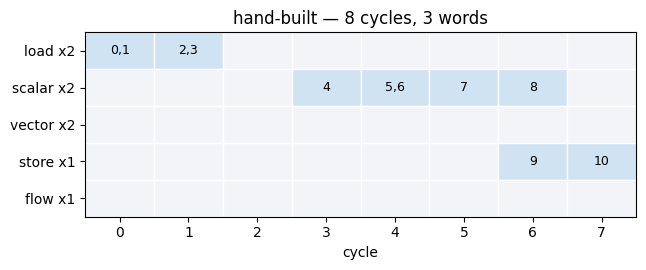

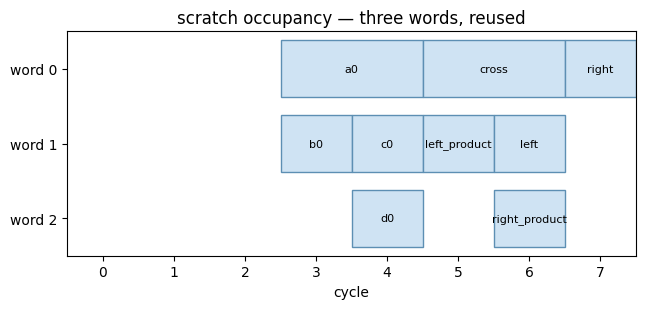

In [12]:
show_timeline(bundles, f"hand-built — {hand_cycles} cycles, {hand_words} words")


def show_lifetimes(addresses, life, span, title):
    """One row per address; each bar is a value occupying it while alive."""
    rows = max(addresses.values()) + 1
    fig, ax = plt.subplots(figsize=(max(4.0, 0.62 * span + 1.6), 0.6 * rows + 1.4))
    for name, base in addresses.items():
        start, end = life[name]
        ax.add_patch(Rectangle((start, base + 0.12), end - start + 1, 0.76,
                               facecolor="#cfe3f3", edgecolor="#5d8fb3"))
        ax.text(start + (end - start + 1) / 2, base + 0.5, name,
                ha="center", va="center", fontsize=8)
    ax.set_xlim(0, span)
    ax.set_ylim(0, rows)
    ax.set_xticks([c + 0.5 for c in range(span)], [str(c) for c in range(span)])
    ax.set_yticks([r + 0.5 for r in range(rows)], [f"word {r}" for r in range(rows)])
    ax.set_xlabel("cycle")
    ax.set_title(title)
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()


show_lifetimes(addresses, life, hand_cycles, "scratch occupancy — three words, reused")

Nine values, three words. Each row is one address being handed from one value to
the next as soon as the previous tenant has been read for the last time.

Worth noticing: this hand-built answer — 8 cycles, 3 words — is exactly what our
index-schema compiler finds for this program. The interesting question is never
"can a person find it", it is "by what procedure does a compiler find it, and
can that procedure prove the answer legal".

---

## 7. Break it three ways

A rule you have not seen enforced is a rule you do not really know. Each cell
below produces an *illegal* compilation on purpose and prints the validator's
complaint. Nothing is silently accepted.

In [13]:
def expect_rejection(label, compilation):
    try:
        machine.check_compilation(program, compilation)
    except machine.CompileError as exc:
        print(f"{label:22} REJECTED -> {exc}")
    else:
        print(f"{label:22} accepted (this would be a bug in our understanding)")


# 1. latency: issue the multiply one cycle before its inputs have landed.
early = {**times, 4: 2}
expect_rejection("too early (latency)", {
    "scratch": lowest_legal_addresses(facts, direct_contract.lifetimes(facts, early)),
    "bundles": direct_contract.assemble_bundles(facts, early),
})

# 2. engine capacity: three scalar operations in a cycle with two scalar slots.
crowded = {**times, 4: 4}
expect_rejection("three in two slots", {
    "scratch": addresses,
    "bundles": direct_contract.assemble_bundles(facts, crowded),
})

# 3. allocation: make two values that are alive together share one address.
aliased = dict(addresses)
aliased["left"] = aliased["cross"]          # cross is live [5..6], left is live [6..6]
expect_rejection("shared while alive", {"scratch": aliased, "bundles": bundles})

too early (latency)    REJECTED -> operation 4 uses 'a0' in cycle 2, but operation 0 produces it in cycle 3
three in two slots     REJECTED -> bundle 4 has 3 scalar operations, limit is 2
shared while alive     REJECTED -> scratch allocations 'left' and 'cross' overlap while live


The third one is the subtle rule, and the one most home-made allocators get
wrong. `cross` is read at cycle 6 and `left` is written at cycle 6. They touch,
so they may not share a word. Had `left` been written at cycle 7 instead, the
same sharing would have been perfectly legal — the difference is a single cycle.

This is also why scheduling and allocation cannot really be decided one after
the other: **the live intervals depend on the schedule you chose.** Move an
operation and every lifetime downstream of it shifts.

---

## 8. What "correct" actually means

Correctness is not "the validator accepted the shape". The grader interprets the
*original operations* directly to get a reference memory image, then runs *your
schedule* on the machine, and compares. Let us see both sides.

In [14]:
case = program["cases"][0]
print("input memory    :", case)
print("reference result:", machine.run_reference(program, case))
print("our schedule    :", machine.run_compilation(program, hand, case))
print()
print("a0*b0 + (a0+c0) =", (13 * 5 + (13 + 21)) % 2**32,
      "   c0*d0 ^ (a0+c0) =", (21 * 9) ^ (13 + 21))

input memory    : {'a': [13], 'b': [5], 'c': [21], 'd': [9], 'out': [0, 0]}
reference result: {'a': [13], 'b': [5], 'c': [21], 'd': [9], 'out': [99, 159]}
our schedule    : {'a': [13], 'b': [5], 'c': [21], 'd': [9], 'out': [99, 159]}

a0*b0 + (a0+c0) = 99    c0*d0 ^ (a0+c0) = 159


Note that these are two separate gates. `check_compilation` looks only at the
shape of your answer; `check_case` actually runs it. Try swapping two addresses,
which looks like a pure relabelling, and watch which gate catches it.

In [15]:
# Swap where the two products live. Each value still has an address, every
# address is in range, and no operation moved.
swapped = dict(addresses)
swapped["left_product"], swapped["right_product"] = (
    swapped["right_product"], swapped["left_product"])

candidate = {"scratch": swapped, "bundles": bundles}
try:
    machine.check_compilation(program, candidate)
    print("structure  : accepted")
    machine.check_case(program, candidate, case)
    print("numbers    : accepted")
except machine.CompileError as exc:
    print("REJECTED ->", exc)

REJECTED -> scratch allocations 'left' and 'right_product' overlap while live


The structural gate caught it: the swap put `left` on a word that
`right_product` still occupies while both are alive. That is the usual outcome
on this machine — a compaction tight enough to be worth doing is almost always
caught structurally when it is wrong, because addresses are only reusable
exactly when lifetimes permit.

Do not read that as "the numeric check is redundant". The grader does not trust
your compiler's reasoning, only its output, and it re-derives the expected
memory from the original operations for every case, public and hidden. If your
compiler ever mis-modelled a latency or an ordering rule, this is the gate that
would say so.

---

## 9. Memory ordering

None of the eight public programs exercises this rule, which makes it easy to
miss and expensive to get wrong on the hidden set. So build a tiny program that
does: read a word, increment it, write it back, read it again.

In [16]:
ordering_demo = {
    "name": "ordering_demo",
    "buffers": {"x": 1, "out": 1},
    "operations": [
        {"id": 0, "op": "load",  "dest": "v0", "buffer": "x", "offset": 0},
        {"id": 1, "op": "const", "dest": "one", "value": 1},
        {"id": 2, "op": "add",   "dest": "v1", "args": ["v0", "one"]},
        {"id": 3, "op": "store", "args": ["v1"], "buffer": "x", "offset": 0},
        {"id": 4, "op": "load",  "dest": "v2", "buffer": "x", "offset": 0},
        {"id": 5, "op": "store", "args": ["v2"], "buffer": "out", "offset": 0},
    ],
    "cases": [{"x": [7], "out": [0]}],
}
machine.validate_program(ordering_demo)

for op in ordering_demo["operations"]:
    earlier = machine.memory_predecessors(ordering_demo, op["id"])
    if earlier:
        print(f"op {op['id']} ({op['op']} {op['buffer']}[{op['offset']}]) must issue "
              f"strictly after {earlier}")
print()
for path in sorted((ROOT / ".reference/programs").glob("*.json")):
    p = machine.load_program(path)
    ordered = sum(1 for op in p["operations"] if machine.memory_predecessors(p, op["id"]))
    print(f"{p['name']:20} operations with a memory predecessor: {ordered}")

op 3 (store x[0]) must issue strictly after [0]
op 4 (load x[0]) must issue strictly after [3]

scalar_pipeline      operations with a memory predecessor: 0
scalar_dual_chain    operations with a memory predecessor: 0
vector_axpy          operations with a memory predecessor: 0
vector_bitmix        operations with a memory predecessor: 0
mixed_broadcast      operations with a memory predecessor: 0
parallel_memory      operations with a memory predecessor: 0
scalar_selects       operations with a memory predecessor: 0
vector_reduction     operations with a memory predecessor: 0


The last column is zero everywhere: the public set never forces an ordering. The
brief says hidden programs use the same documented rules, so a compiler that
quietly ignores `memory_predecessors` can score well on all eight visible
programs and then produce wrong memory on a hidden one. Note the second half of
the rule too — ordered memory operations must be in **different** cycles, not
merely in the right order.

---

## 10. The score

The formula lives in `.reference/score.py` and is short:

- per program, `speedup = baseline_cycles / your_cycles` and
  `reduction = baseline_words / your_words`, where the baseline is the frozen
  `machine.serial_compile`;
- take the **geometric** mean of each across programs;
- the combined score is `sqrt(cycle_geomean * scratch_geomean)`.

Geometric rather than arithmetic means ratios compose symmetrically: halving the
cycles and doubling them cancel out, which an arithmetic mean would not do. The
square root gives the two objectives equal weight.

In [17]:
baseline = machine.serial_compile(program)
baseline_cycles = machine.check_compilation(program, baseline)
baseline_words = machine.scratch_footprint(program, baseline)

for label, cycles, words in (
    ("starter", starter_cycles, starter_words),
    ("hand-built", hand_cycles, hand_words),
):
    speedup = baseline_cycles / cycles
    reduction = baseline_words / words
    print(f"{label:11} {cycles:3d} cycles ({speedup:.3f}x)  {words:3d} words "
          f"({reduction:.3f}x)  combined {math.sqrt(speedup * reduction):.3f}x")

print(f"\nbaseline: {baseline_cycles} cycles, {baseline_words} words")

starter      12 cycles (1.000x)    9 words (1.000x)  combined 1.000x
hand-built    8 cycles (1.500x)    3 words (3.000x)  combined 2.121x

baseline: 12 cycles, 9 words


The starter scores exactly 1.000x by construction — it *is* the baseline. Our
hand-built schedule scores 2.121x on this program: 1.5x on cycles and 3.0x on
words.

Two things follow that are easy to miss:

1. **Scratch is the softer target.** Cycles are bounded from below by the
   dependency chain, which you cannot shorten. Footprint is bounded only by peak
   overlap, and peak overlap is itself something scheduling can change.
2. **The public score is not the graded score.** Grading runs the same formula
   over sixteen programs — the eight you can see plus eight you cannot. Anything
   tuned to the visible eight is worth nothing on the other half.

---

## 11. Running the challenge yourself

Everything below runs from `luminal-challenge/.reference/`. The candidate task is
to rewrite `compile_program()` in `compiler.py`; `machine.py`, the programs and
the tests are off limits.

```sh
cd luminal-challenge/.reference

python3 -m unittest -v          # the public test suite
python3 score.py                # the public benchmark table

# compile one program and validate the result
python3 compiler.py programs/03_vector_axpy.json > /tmp/axpy.schedule.json
python3 machine.py programs/03_vector_axpy.json /tmp/axpy.schedule.json
```

The last command prints `OK: vector_axpy, cases=..., cycles=...` or `INVALID:`
with the reason. That pair — compile to stdout, validate — is the whole
development loop.

Rules from the brief worth keeping in front of you:

- Up to **four hours**, reading and testing included; submit what you have.
- The CLI must print **only** the schedule JSON on stdout; diagnostics go to
  stderr. The grader allows **20 seconds per program**.
- AI tools are allowed and must be **disclosed**, together with how you checked
  their output.
- Do **not** share the exercise or a solution publicly, and do not collaborate.
  (This is why the work in this repository stays local and unpushed.)

Run the benchmark now to see the starting point for yourself.

In [18]:
import subprocess

result = subprocess.run([sys.executable, "score.py"], cwd=ROOT / ".reference",
                        capture_output=True, text=True)
print(result.stdout or result.stderr)

Luminal Compiler Take Home — compiler engineering public benchmark
program                          cycles  baseline   speedup  scratch  reduction
------------------------------------------------------------
scalar_pipeline                      18        18    1.000x       15     1.000x
scalar_dual_chain                    12        12    1.000x        9     1.000x
vector_axpy                          14        14    1.000x       73     1.000x
vector_bitmix                        16        16    1.000x       89     1.000x
mixed_broadcast                      11        11    1.000x       42     1.000x
parallel_memory                      21        21    1.000x      128     1.000x
scalar_selects                       20        20    1.000x       16     1.000x
vector_reduction                     19        19    1.000x      137     1.000x
------------------------------------------------------------
public geometric-mean speedup: 1.000x
public geometric-mean scratch reduction: 1.000x
publi

---

## 12. Where to go next

You now have the whole contract: a fixed list of operations, a machine with
slots and latencies, 256 words of scratch, and a score that rewards shorter
schedules and smaller footprints without ever forgiving a wrong answer.

The standard way forward — and the one the brief itself suggests — is a greedy
list scheduler: keep a ready queue, prioritise operations on the critical path,
fill each bundle, then allocate by scanning live intervals.

The approach taken in this repository is different, and the next notebooks cover
it: every scheduling and allocation decision is expressed as a **query over
Boolean index schemata**, so that "is this placement legal?" is answered by
intersecting sets of bit patterns rather than by a heuristic rule. Its measured
result on the eight public programs is a combined **2.008x** against **1.901x**
for a conventional greedy baseline — better on three programs, equal on four,
worse on one — at roughly 1,500 times the compile time. Both halves of that
sentence matter.

Suggested exercises before moving on:

1. Change one entry in `times` in §5 and re-run §6 and §7. Which lifetimes move?
   Does the footprint change?
2. Schedule `01_scalar_pipeline.json` by hand with the same method and compare
   your score against the starter.
3. Add a second `store` to the same address in §9 and confirm the validator
   forces the two into different cycles.